# Comparaison des deux datasets

**Objectif** : comparer les deux datasets sur les variables qu'ils ont en commun, puis décider du
rôle de chacun.

- `data/agriculture-crop-yield/crop_yield.csv` : une ligne = une parcelle sur une saison.
- `data/processed/crop_yield_clean.csv` : dataset historique nettoyé (notebook 04), une ligne = un
  pays, une année, une culture.

## Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from agritech import utils
from agritech.config import AGRICULTURE_CROP_YIELD_FILENAME, PATHS, SEED

## Lecture des datasets

In [2]:
df_hist = pd.read_csv(PATHS.data_processed / "crop_yield_clean.csv")

In [3]:
csv_path = PATHS.data_agriculture_crop_yield / AGRICULTURE_CROP_YIELD_FILENAME
df_agri = pd.read_csv(csv_path)

## Vue d'ensemble

In [4]:
print("Taille (lignes x colonnes)")
print("  - historique :", df_hist.shape)
print("  - agri   :", df_agri.shape)

print("\nUne ligne")
print("  - historique : pays x année x culture")
print("  - agri   : une parcelle sur une saison")

print("\nPériode")
print(f"  - historique : {df_hist.year.min()} - {df_hist.year.max()}")
print("  - agri   : aucune colonne de temps")

print("\nColonnes")
print("  - historique :", df_hist.columns.tolist())
print("  - agri   :", df_agri.columns.tolist())

Taille (lignes x colonnes)
  - historique : (16319, 8)
  - agri   : (1000000, 10)

Une ligne
  - historique : pays x année x culture
  - agri   : une parcelle sur une saison

Période
  - historique : 1990 - 2013
  - agri   : aucune colonne de temps

Colonnes
  - historique : ['iso3', 'area', 'year', 'crop', 'yield_t_ha', 'avg_temp', 'rain_mm', 'pesticides_t']
  - agri   : ['Region', 'Soil_Type', 'Crop', 'Rainfall_mm', 'Temperature_Celsius', 'Fertilizer_Used', 'Irrigation_Used', 'Weather_Condition', 'Days_to_Harvest', 'Yield_tons_per_hectare']


**Observations :**

- Une ligne ne représente pas la même chose : une parcelle d'un côté, un pays une année donnée de
  l'autre.
- Seul l'historique contient des années.

## Variables communes

In [5]:
print("Rendement")
print(f"  - historique : {df_hist.yield_t_ha.min():.2f} - {df_hist.yield_t_ha.max():.2f} (yield_t_ha)")
print(f"  - agri   : {df_agri.Yield_tons_per_hectare.min():.2f} - "
      f"{df_agri.Yield_tons_per_hectare.max():.2f} (Yield_tons_per_hectare)")

print("\nTempérature")
print(f"  - historique : {df_hist.avg_temp.min():.2f} - {df_hist.avg_temp.max():.2f} (avg_temp)")
print(f"  - agri   : {df_agri.Temperature_Celsius.min():.2f} - "
      f"{df_agri.Temperature_Celsius.max():.2f} (Temperature_Celsius)")

print("\nPluie")
print(f"  - historique : {df_hist.rain_mm.min():.0f} - {df_hist.rain_mm.max():.0f} (rain_mm)")
print(f"  - agri   : {df_agri.Rainfall_mm.min():.0f} - {df_agri.Rainfall_mm.max():.0f} (Rainfall_mm)")

print("\nCultures")
print("  - historique :", sorted(df_hist.crop.unique()))
print("  - agri   :", sorted(df_agri.Crop.unique()))

Rendement
  - historique : 0.01 - 50.14 (yield_t_ha)
  - agri   : -1.15 - 9.96 (Yield_tons_per_hectare)

Température
  - historique : 1.30 - 30.42 (avg_temp)
  - agri   : 15.00 - 40.00 (Temperature_Celsius)

Pluie
  - historique : 51 - 3240 (rain_mm)
  - agri   : 100 - 1000 (Rainfall_mm)

Cultures
  - historique : ['Cassava', 'Maize', 'Plantains and others', 'Potatoes', 'Rice, paddy', 'Sorghum', 'Soybeans', 'Sweet potatoes', 'Wheat', 'Yams']
  - agri   : ['Barley', 'Cotton', 'Maize', 'Rice', 'Soybean', 'Wheat']


**Observations :**

- Trois variables existent dans les deux datasets, avec les mêmes unités : rendement, température,
  pluie.
- La pluie n'a pas le même sens : valeur de pluie fixe par pays dans le fichier historique, pluie
  de la saison dans Agriculture CropYield.

### Variables sans équivalent

In [6]:
print("Localisation")
print("  - historique (area) :", df_hist.area.unique().tolist()[:5], "...")
print("  - agri   (Region) :", df_agri.Region.unique().tolist())

print("\nIntrants")
print(f"  - historique : pesticides_t, {df_hist.pesticides_t.min():.0f} - "
      f"{df_hist.pesticides_t.max():.0f} tonnes déclarées par pays et par année")
print("  - agri   : Fertilizer_Used, Irrigation_Used, deux booléens à l'échelle de la parcelle")

Localisation
  - historique (area) : ['Albania', 'Algeria', 'Angola', 'Argentina', 'Armenia'] ...
  - agri   (Region) : ['West', 'South', 'North', 'East']

Intrants
  - historique : pesticides_t, 0 - 1806000 tonnes déclarées par pays et par année
  - agri   : Fertilizer_Used, Irrigation_Used, deux booléens à l'échelle de la parcelle


**Observations :**

- `Region` (North, East, South, West) ne correspond à aucun pays.
- Les pesticides sont un tonnage national, alors que l'engrais et l'irrigation décrivent une
  parcelle : pas d'équivalence possible.
- `Soil_Type`, `Fertilizer_Used`, `Irrigation_Used`, `Weather_Condition` et `Days_to_Harvest`
  n'existent pas dans l'historique.

## Cultures communes

Deux noms s'écrivent différemment : `Rice, paddy` devient `Rice` et `Soybeans` devient `Soybean`.

In [7]:
df_hist["crop"] = df_hist["crop"].replace({"Rice, paddy": "Rice", "Soybeans": "Soybean"})

cultures_hist = set(df_hist.crop.unique())
cultures_agri = set(df_agri.Crop.unique())

COMMUNES = sorted(cultures_hist & cultures_agri)

print("Communes                :", COMMUNES)
print("Seulement dans l'historique :", sorted(cultures_hist - cultures_agri))
print("Seulement dans agri     :", sorted(cultures_agri - cultures_hist))

Communes                : ['Maize', 'Rice', 'Soybean', 'Wheat']
Seulement dans l'historique : ['Cassava', 'Plantains and others', 'Potatoes', 'Sorghum', 'Sweet potatoes', 'Yams']
Seulement dans agri     : ['Barley', 'Cotton']


**Observations :**

- 4 cultures communes : maïs, riz, soja et blé.
- La suite compare les deux datasets sur ces 4 cultures seulement.

In [8]:
hist_communes = df_hist.query("crop in @COMMUNES")
agri_communes = df_agri.query("Crop in @COMMUNES")

print(f"historique : {len(hist_communes)} lignes, {hist_communes.iso3.nunique()} pays")
print(f"agri       : {len(agri_communes)} lignes")
print("valeurs manquantes de l'historique :", hist_communes.isna().sum().sum())

historique : 8237 lignes, 115 pays
agri       : 666638 lignes
valeurs manquantes de l'historique : 0


**Observations :**

- 8 237 lignes dans l'historique (115 pays), 666 638 dans Agriculture CropYield.
- Aucune valeur manquante dans l'historique.

## Comparaison des distributions

Un boxplot par culture, une couleur par dataset.

In [9]:
DATASETS = ["Historique nettoyé", "Agriculture CropYield"]

# libellé affiché -> (colonne de l'historique, colonne d'Agriculture CropYield)
VARIABLES = {
    "rendement (t/ha)": ("yield_t_ha", "Yield_tons_per_hectare"),
    "température (°C)": ("avg_temp", "Temperature_Celsius"),
    "pluie (mm)": ("rain_mm", "Rainfall_mm"),
}


def empile(libelle):
    """Met les deux datasets à la suite pour une variable commune."""
    col_hist, col_agri = VARIABLES[libelle]

    historique = (
        hist_communes[["crop", col_hist]]
        .rename(columns={col_hist: libelle})
        .assign(dataset=DATASETS[0])
    )
    agri = (
        agri_communes[["Crop", col_agri]]
        .rename(columns={"Crop": "crop", col_agri: libelle})
        .assign(dataset=DATASETS[1])
    )
    return pd.concat([historique, agri], ignore_index=True)


def boxplot_compare(libelle):
    """Compare la distribution d'une variable, par culture et par dataset."""
    plt.figure(figsize=(10, 5))
    sns.boxplot(
        data=empile(libelle),
        x="crop",
        y=libelle,
        hue="dataset",
        order=COMMUNES,
        hue_order=DATASETS,
    )
    plt.xlabel("Culture")
    plt.ylabel(libelle)
    plt.title(f"Distribution — {libelle}")
    plt.legend(title="Dataset", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

### Rendement par culture

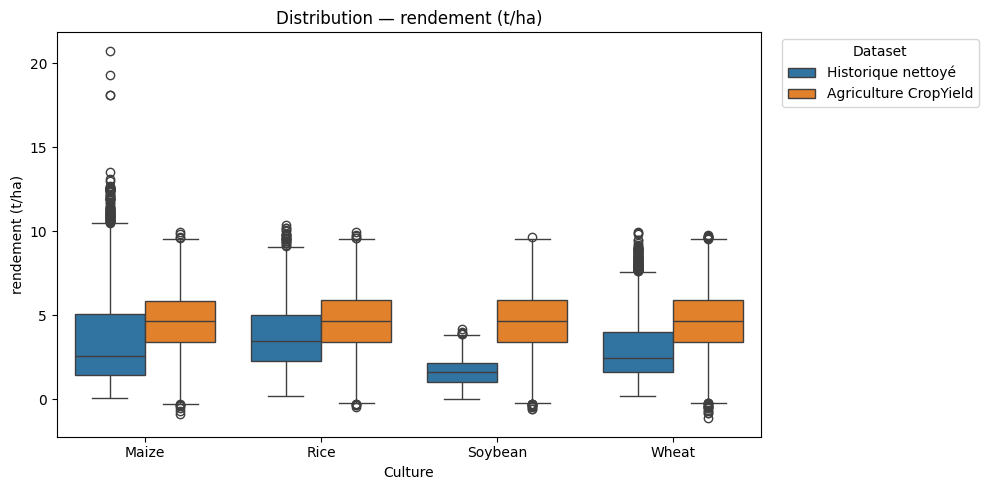

In [10]:
boxplot_compare("rendement (t/ha)")

**Observations :**

- Agriculture CropYield : les 4 cultures ont la même distribution de rendement.
- Historique : chaque culture a son propre niveau de rendement.

### Température par culture

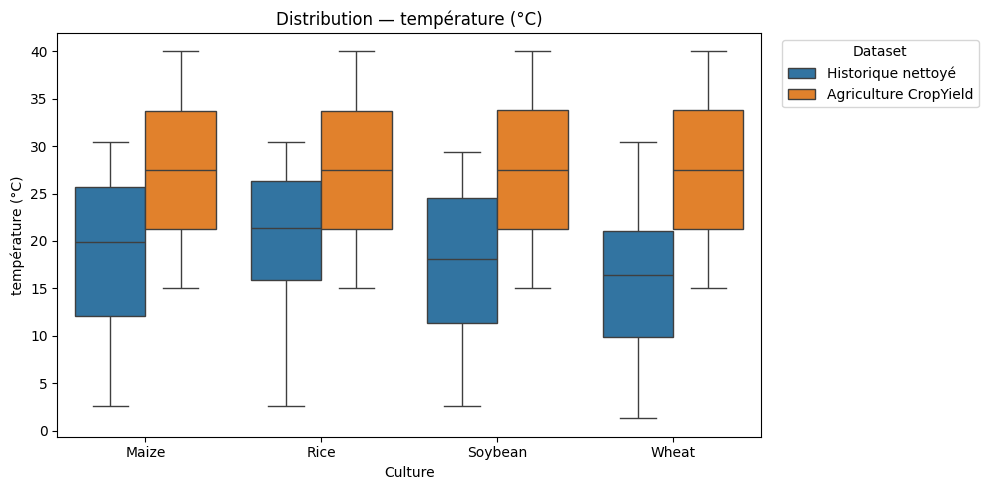

In [11]:
boxplot_compare("température (°C)")

**Observations :**

- Agriculture CropYield : même distribution pour les 4 cultures, de 15 à 40 °C.
- Historique : températures plus basses (1,3 à 30,4 °C) ; le blé est cultivé dans des pays plus
  frais (médiane 16,4 °C) que le riz (21,3 °C).

### Pluie par culture

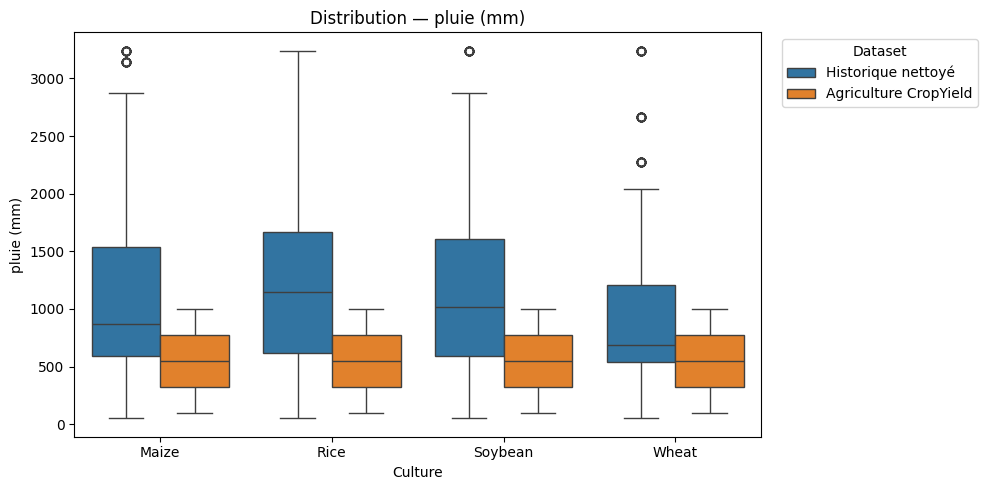

In [12]:
boxplot_compare("pluie (mm)")

**Observations :**

- L'historique dépasse souvent 1 000 mm, le maximum d'Agriculture CropYield.
- Comparaison à prendre avec prudence : les deux pluies ne mesurent pas la même chose.

## Chiffres clés des cultures communes

Médiane, moyenne et écart-type des trois variables, par culture et par dataset.

In [13]:
def stats_par_culture(df, colonne_culture, colonnes):
    """Médiane, moyenne et écart-type par culture, pour chaque variable comparable."""
    tables = {}
    for libelle, colonne in colonnes.items():
        tables[libelle] = df.groupby(colonne_culture)[colonne].agg(["median", "mean", "std"])
    return pd.concat(tables, names=["variable", "culture"])


synthese = pd.concat(
    {
        DATASETS[0]: stats_par_culture(
            hist_communes, "crop", {k: v[0] for k, v in VARIABLES.items()}
        ),
        DATASETS[1]: stats_par_culture(
            agri_communes, "Crop", {k: v[1] for k, v in VARIABLES.items()}
        ),
    },
    axis=1,
).rename(columns={"median": "médiane", "mean": "moyenne", "std": "écart-type"})

synthese.round(2)

Historique nettoyé                      \
                                    médiane  moyenne écart-type   
variable         culture                                          
rendement (t/ha) Maize                 2.55     3.67       2.98   
                 Rice                  3.47     3.78       1.97   
                 Soybean               1.58     1.63       0.75   
                 Wheat                 2.45     3.02       1.98   
température (°C) Maize                19.91    18.93       7.03   
                 Rice                 21.34    20.43       6.47   
                 Soybean              18.13    17.88       6.76   
                 Wheat                16.37    16.11       6.84   
pluie (mm)       Maize               867.00  1089.20     715.05   
                 Rice               1146.00  1205.74     746.25   
                 Soybean            1020.00  1102.80     668.49   
                 Wheat               691.00   894.15     599.58   

                         Agriculture CropYield                     
                                       médiane moyenne écart-type  
variable         culture                                           
rendement (t/ha) Maize                    4.64    4.64       1.70  
                 Rice                     4.65    4.65       1.70  
                 Soybean                  4.66    4.65       1.70  
                 Wheat                    4.66    4.65       1.69  
température (°C) Maize                   27.47   27.48       7.22  
                 Rice                    27.53   27.50       7.20  
                 Soybean                 27.50   27.51       7.23  
                 Wheat                   27.51   27.52       7.22  
pluie (mm)       Maize                  549.67  549.20     259.90  
                 Rice                   550.40  550.51     259.84  
                 Soybean                551.69  550.47     259.60  
                 Wheat                  550.47  550.25     259.77

**Observations :**

- Agriculture CropYield : mêmes valeurs pour les 4 cultures (rendement médian 4,64 à 4,66 t/ha,
  27,5 °C, 550 mm).
- Historique : rendement médian de 1,58 t/ha (soja) à 3,47 t/ha (riz).
- Historique : le blé correspond à des pays plus frais et plus secs (16,4 °C, 691 mm) que le riz
  (21,3 °C, 1 146 mm).

## Température et pluie par culture

Les deux datasets sur les mêmes axes, avec 4 000 points tirés au hasard dans chacun.

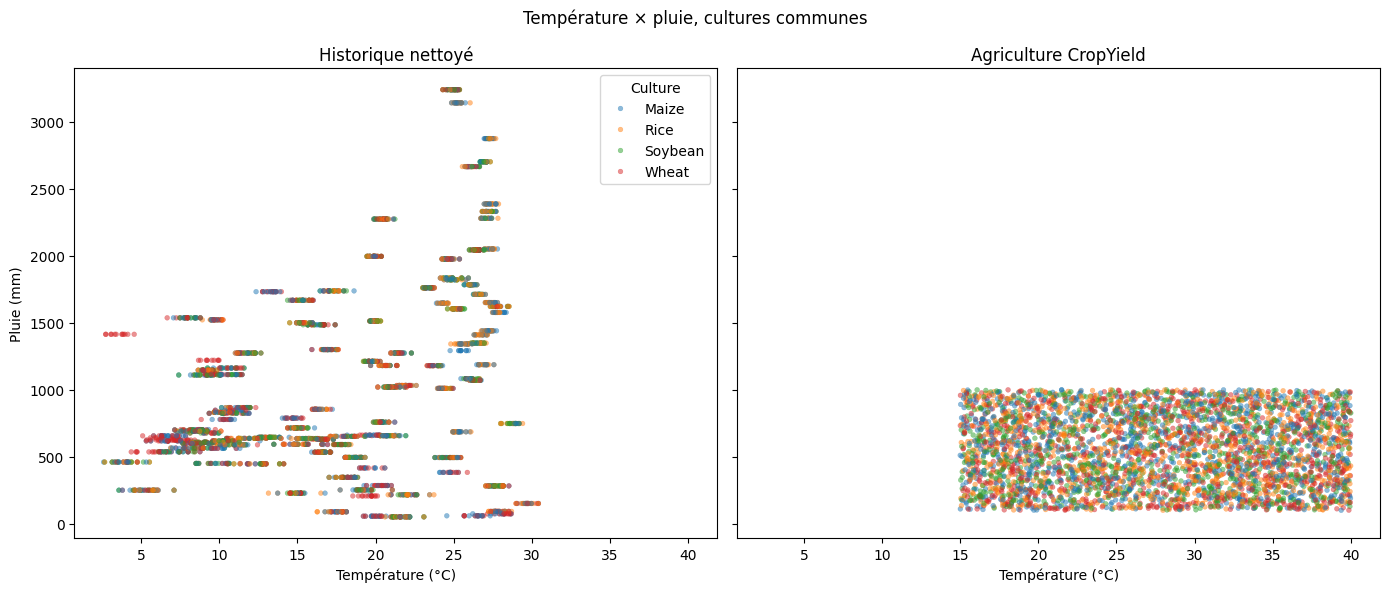

In [14]:
TAILLE_ECHANTILLON = 4_000

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

sns.scatterplot(
    data=hist_communes.sample(TAILLE_ECHANTILLON, random_state=SEED),
    x="avg_temp", y="rain_mm", hue="crop", hue_order=COMMUNES,
    s=12, alpha=0.5, edgecolor=None, ax=axes[0],
)
axes[0].set_title(DATASETS[0])
axes[0].legend(title="Culture", loc="upper right")

sns.scatterplot(
    data=agri_communes.sample(TAILLE_ECHANTILLON, random_state=SEED),
    x="Temperature_Celsius", y="Rainfall_mm", hue="Crop", hue_order=COMMUNES,
    s=12, alpha=0.5, edgecolor=None, ax=axes[1],
)
axes[1].set_title(DATASETS[1])
axes[1].get_legend().remove()

for ax in axes:
    ax.set_xlabel("Température (°C)")
    ax.set_ylabel("Pluie (mm)")

fig.suptitle("Température × pluie, cultures communes")
fig.tight_layout()
plt.show()

**Observations :**

- Agriculture CropYield : les points remplissent un rectangle (15-40 °C, 100-1 000 mm) et les
  cultures sont mélangées.
- Historique : lignes horizontales, car la pluie est fixe pour un pays ; les cultures se
  recouvrent aussi.
- Les deux nuages ne se recouvrent que sur une petite zone.

## Relations avec le rendement

Corrélations de Pearson avec le rendement, sur les cultures communes. Les pesticides n'existent que
dans l'historique.

In [15]:
corr_hist = hist_communes[["avg_temp", "rain_mm", "pesticides_t"]].corrwith(
    hist_communes["yield_t_ha"]
)
corr_agri = agri_communes[["Temperature_Celsius", "Rainfall_mm"]].corrwith(
    agri_communes["Yield_tons_per_hectare"]
)

pd.DataFrame(
    {
        DATASETS[0]: corr_hist.rename(
            {"avg_temp": "température", "rain_mm": "pluie", "pesticides_t": "pesticides"}
        ),
        DATASETS[1]: corr_agri.rename(
            {"Temperature_Celsius": "température", "Rainfall_mm": "pluie"}
        ),
    }
).reindex(["température", "pluie", "pesticides"]).round(3)

,Historique nettoyé,Agriculture CropYield
température,-0.315,0.085
pluie,-0.104,0.764
pesticides,0.110,NaN


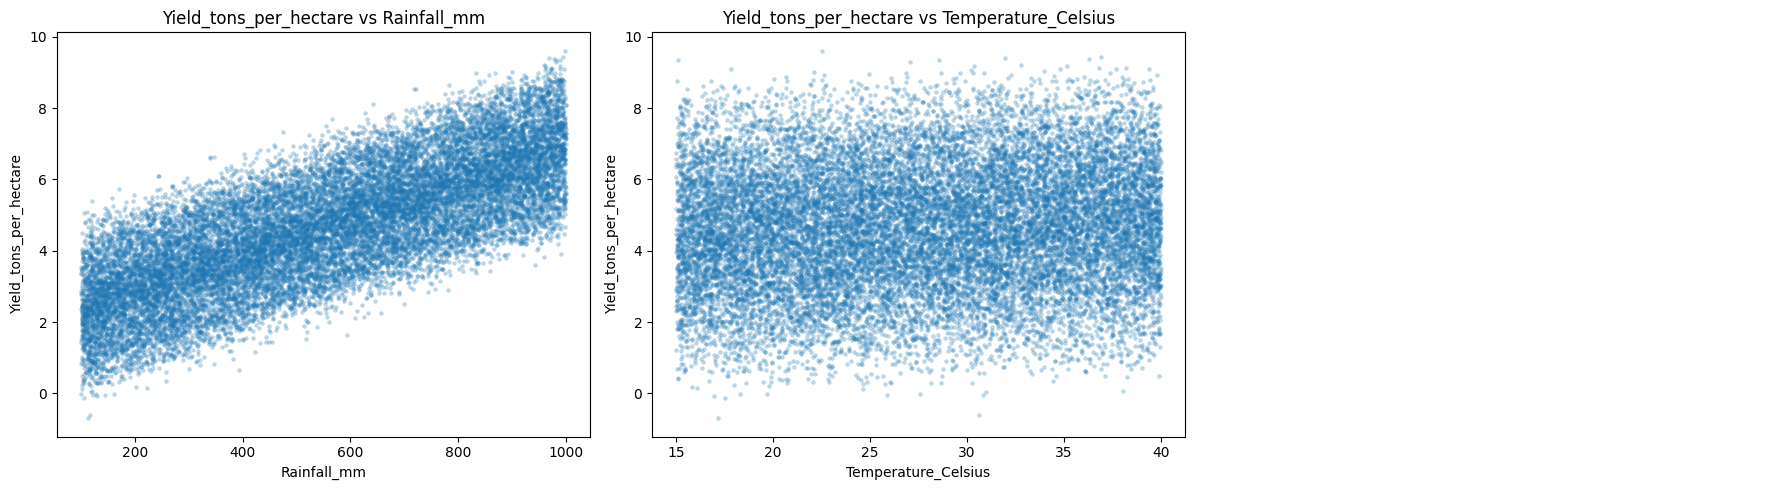

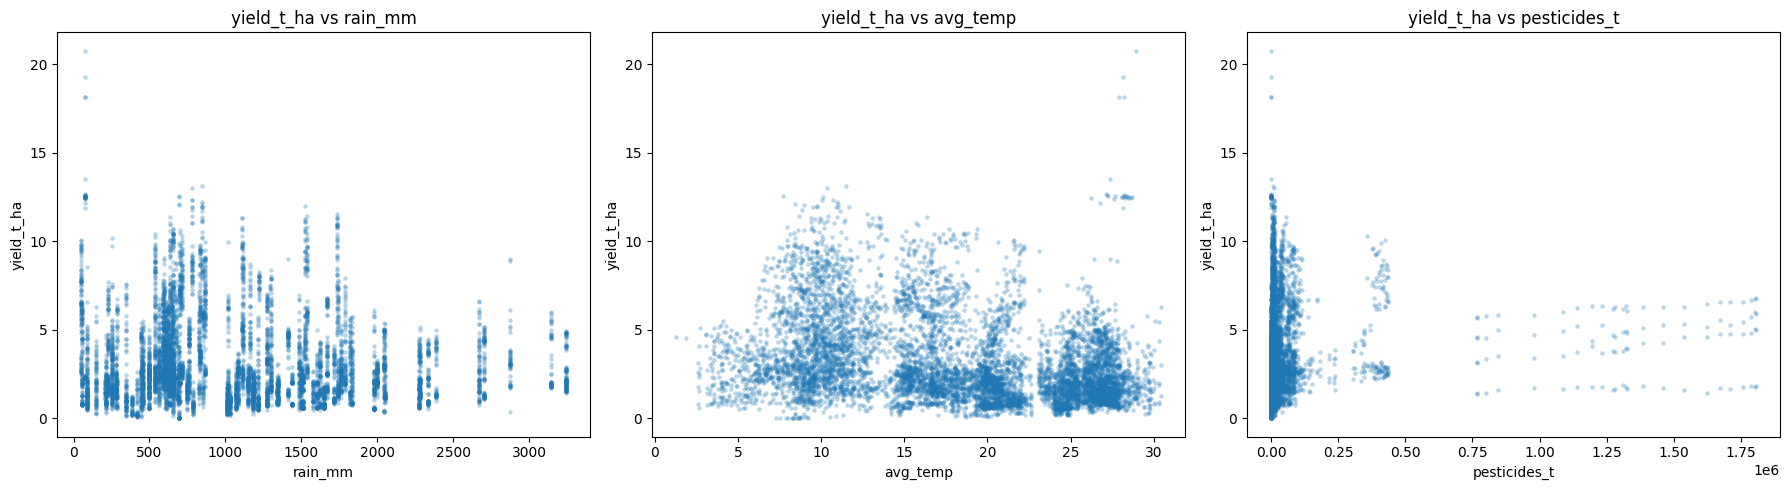

In [16]:
utils.plot_pairs(
    agri_communes,
    "Yield_tons_per_hectare",
    ["Rainfall_mm", "Temperature_Celsius"],
)
utils.plot_pairs(
    hist_communes,
    "yield_t_ha",
    ["rain_mm", "avg_temp", "pesticides_t"],
)

**Observations :**

- Les corrélations changent de signe : pluie +0,764 dans Agriculture CropYield contre −0,104 dans
  l'historique ; température +0,085 contre −0,315.
- Dans l'historique, elles comparent des pays entre eux : ce n'est pas l'effet de la pluie sur une
  parcelle.
- Pesticides en valeur brute : 0,110 ; le logarithme est testé juste après.

### Pesticides : valeur brute ou logarithme ?

Tonnage national de pesticides et rendement, pour les 10 cultures de l'historique.

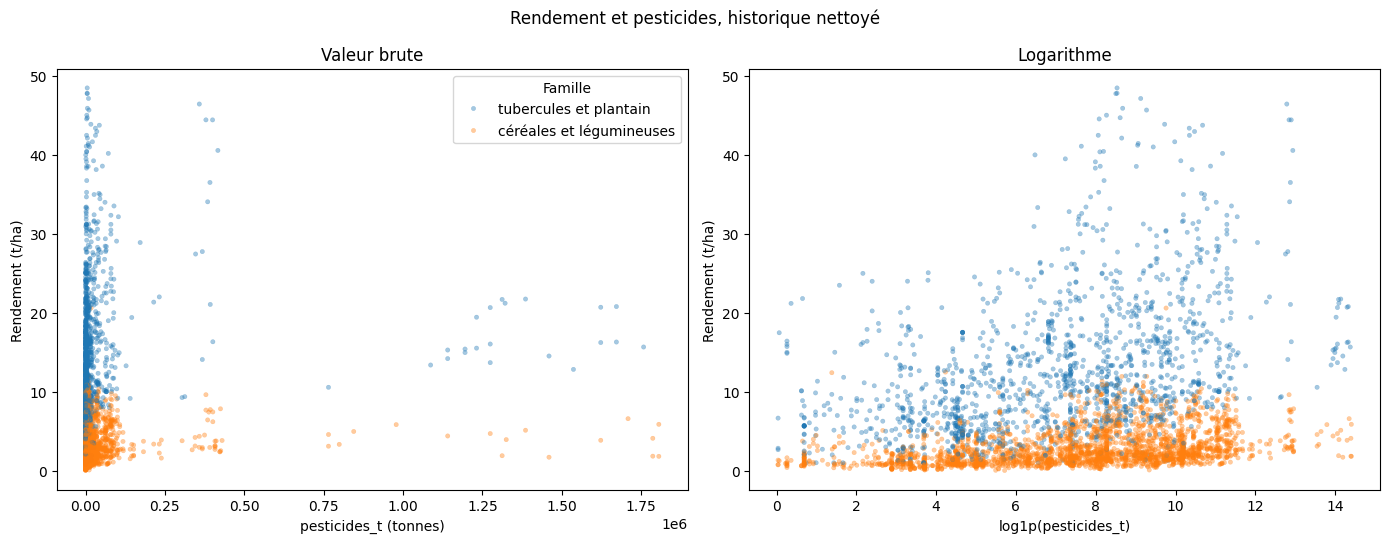

In [17]:
TUBERCULES = ["Potatoes", "Cassava", "Sweet potatoes", "Yams", "Plantains and others"]

pesticides = df_hist.copy()
assert pesticides["pesticides_t"].ge(0).all()
pesticides["log_pesticides"] = np.log1p(pesticides["pesticides_t"])
assert np.isfinite(pesticides["log_pesticides"]).all()
pesticides["famille"] = np.where(
    pesticides["crop"].isin(TUBERCULES), "tubercules et plantain", "céréales et légumineuses"
)

echantillon = pesticides.sample(TAILLE_ECHANTILLON, random_state=SEED)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, colonne, libelle in [
    (axes[0], "pesticides_t", "pesticides_t (tonnes)"),
    (axes[1], "log_pesticides", "log1p(pesticides_t)"),
]:
    sns.scatterplot(
        data=echantillon, x=colonne, y="yield_t_ha", hue="famille",
        s=10, alpha=0.4, edgecolor=None, ax=ax,
    )
    ax.set_xlabel(libelle)
    ax.set_ylabel("Rendement (t/ha)")

axes[0].set_title("Valeur brute")
axes[1].set_title("Logarithme")
axes[0].legend(title="Famille", loc="upper right")
axes[1].get_legend().remove()
fig.suptitle("Rendement et pesticides, historique nettoyé")
fig.tight_layout()
plt.show()

In [18]:
lignes = []
for culture, groupe in pesticides.groupby("crop"):
    lignes.append({
        "culture": culture,
        "brut": groupe["yield_t_ha"].corr(groupe["pesticides_t"]),
        "log1p": groupe["yield_t_ha"].corr(groupe["log_pesticides"]),
    })

pd.DataFrame(lignes).set_index("culture").sort_values("log1p", ascending=False).round(2)

,brut,log1p
culture,,
Rice,0.24,0.56
Sorghum,0.26,0.54
Soybean,0.12,0.50
Potatoes,0.08,0.48
Sweet potatoes,0.26,0.46
Plantains and others,0.07,0.45
Maize,0.13,0.41
Yams,0.16,0.37
Cassava,0.17,0.27


**Observations :**

- En valeur brute, la plupart des points sont écrasés à gauche : corrélations de 0,07 à 0,26 selon
  la culture.
- Avec `log1p`, les points s'étalent et les corrélations montent à 0,26-0,56.
- Une corrélation plus forte ne garantit pas de meilleures prédictions : brut et log seront comparés lors de la modélisation.

## Ce que l'historique confirme ou non

- Les rendements d'Agriculture CropYield (médiane 4,65 t/ha) restent dans la plage de l'historique,
  mais au-dessus de ses médianes (1,58 à 3,47 t/ha).
- Les distributions des deux datasets ne se superposent pas.
- Les corrélations ne portent pas sur la même échelle : l'historique ne peut ni confirmer ni
  contredire ce qui est observé sur les parcelles.

## Les cultures se distinguent-elles ?

Rendement moyen par culture et par tranche de température, entre 15 et 30 °C (valeurs présentes
dans les deux datasets).

In [19]:
BANDES = [15, 20, 25, 30]


def rendement_par_bande(df, colonne_temp, colonne_culture, colonne_rendement):
    """Rendement moyen par tranche de température et par culture, avec l'écart entre cultures."""
    bandes = pd.cut(df[colonne_temp], BANDES)
    table = df.pivot_table(
        index=bandes, columns=colonne_culture, values=colonne_rendement, observed=True
    )
    table["écart max"] = table.max(axis=1) - table.min(axis=1)
    return table.round(2)


print(DATASETS[0])
print(rendement_par_bande(hist_communes, "avg_temp", "crop", "yield_t_ha"), "\n")
print(DATASETS[1])
print(rendement_par_bande(agri_communes, "Temperature_Celsius", "Crop", "Yield_tons_per_hectare"))

Historique nettoyé
crop      Maize  Rice  Soybean  Wheat  écart max
avg_temp                                        
(15, 20]   3.79  5.07     1.69   2.10       3.38
(20, 25]   2.00  2.92     1.47   2.37       1.45
(25, 30]   2.48  3.08     1.37   2.16       1.70 

Agriculture CropYield
Crop                 Maize  Rice  Soybean  Wheat  écart max
Temperature_Celsius                                        
(15, 20]              4.44  4.45     4.45   4.46       0.01
(20, 25]              4.53  4.55     4.56   4.56       0.03
(25, 30]              4.65  4.66     4.64   4.66       0.02


**Observations :**

- Agriculture CropYield : 0,01 à 0,03 t/ha d'écart entre cultures, impossible de les classer.
- Historique : 1,45 à 3,38 t/ha d'écart, et l'ordre maïs / blé change selon la température.
- Un classement des cultures est donc possible avec l'historique, pour le contexte d'un pays.

## Conclusion

- `/predict` utilise Agriculture CropYield : le rendement d'une parcelle est prédit à partir de ses
  conditions.
- `/recommend` utilise le dataset historique nettoyé : le pays sert à préremplir la température, la
  pluie et les pesticides, que l'utilisateur peut modifier ; le modèle prédit ensuite le rendement
  des 10 cultures et les classe. `iso3` et `year` seront testés comme variables candidates lors de
  la modélisation.
- Le classement reste indicatif : il repose sur des moyennes de pays.
- Rendement prédit ≠ rentabilité : aucune donnée économique n'est disponible.